In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import importlib.util

In [28]:
# 1. Bypass the broken __init__.py and load models directly from the file
path_to_models = os.path.abspath(os.path.join('..', 'src', 'models.py'))
spec = importlib.util.spec_from_file_location("models_direct", path_to_models)
models_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(models_module)

GAT_Model = models_module.GAT_Model
GATv2_Model = models_module.GATv2_Model

print("✅ Models loaded successfully!")

✅ Models loaded successfully!


In [22]:
# The "Neighbor Scaling" Test -- see how many "noise" neighbors a model could ignore before it started getting confused.

In [40]:
def generate_noisy_dictionary(num_nodes=50, k=1):
    adj = torch.zeros((num_nodes, num_nodes))
    half = num_nodes // 2
    
    # Connect correct pairs (Query i -> Key i + half)
    for i in range(half):
        adj[i, i + half] = 1
        
    if k > 1:
        for i in range(half):
            noise_pool = [j for j in range(half, num_nodes) if j != (i + half)]
            
            # --- THE FIX: Cap the sample size ---
            # You can't pick more neighbors than exist in the pool
            actual_k = min(k - 1, len(noise_pool)) 
            
            noise_targets = np.random.choice(noise_pool, actual_k, replace=False)
            for t in noise_targets:
                adj[i, t] = 1
    
    for i in range(half, num_nodes):
        adj[i, i] = 1
            
    return adj

num_nodes = 200 
nfeat = 8 
nclass = 200

# Features: One-hot identity matrix (unique fingerprint for each node)
x = torch.randn((num_nodes, nfeat))

# Labels: Node i should predict the index of its partner
labels = torch.zeros(num_nodes, dtype=torch.long)
for i in range(num_nodes // 2):
    labels[i] = i + (num_nodes // 2)
for i in range(num_nodes // 2, num_nodes):
    labels[i] = i # Keys point to themselves

print(f"✅ Data ready: {num_nodes} nodes, features {x.shape}")

✅ Data ready: 200 nodes, features torch.Size([200, 8])


In [41]:
def train_and_eval(model, x, adj, labels, epochs=1000):
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(x, adj)
        loss = F.nll_loss(out, labels)
        loss.backward()
        optimizer.step()
    
    model.eval()
    with torch.no_grad():
        out = model(x, adj)
        acc = (out.argmax(1) == labels).float().mean().item()
    return acc

# The Scaling Sweep
neighbor_counts = [1, 2, 4, 8, 16, 32]
gat_results = []
gatv2_results = []

for k in neighbor_counts:
    print(f"Running Test for k={k}...")
    adj = generate_noisy_dictionary(num_nodes, k)
    

    # Test Standard GAT
    model_gat = GAT_Model(nfeat=nfeat, nhid=8, nclass=nclass, dropout=0.1, alpha=0.2, nheads=4)
    acc_gat = train_and_eval(model_gat, x, adj, labels)
    gat_results.append(acc_gat)
    
    # Test GATv2
    model_v2  = GATv2_Model(nfeat=nfeat, nhid=8, nclass=nclass, dropout=0.1, alpha=0.2, nheads=4)
    acc_v2 = train_and_eval(model_v2, x, adj, labels)
    gatv2_results.append(acc_v2)



Running Test for k=1...
Running Test for k=2...
Running Test for k=4...
Running Test for k=8...
Running Test for k=16...
Running Test for k=32...


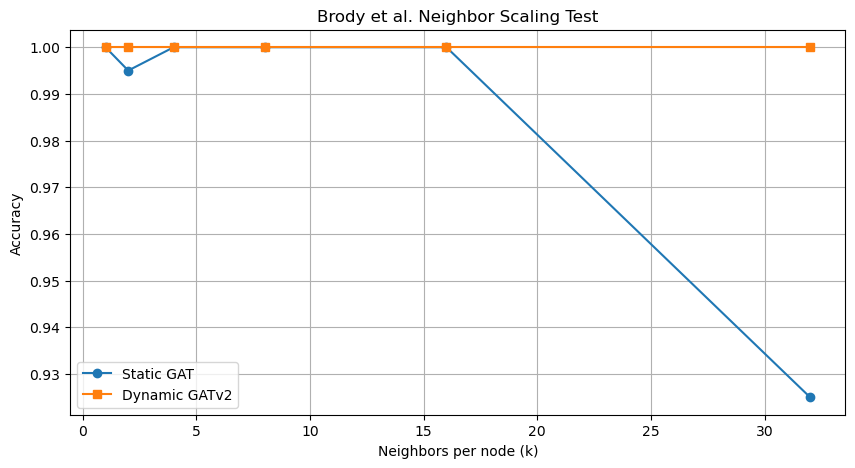

In [42]:
# Final Visualization
plt.figure(figsize=(10, 5))
plt.plot(neighbor_counts, gat_results, 'o-', label='Static GAT')
plt.plot(neighbor_counts, gatv2_results, 's-', label='Dynamic GATv2')
plt.xlabel('Neighbors per node (k)')
plt.ylabel('Accuracy')
plt.title('Brody et al. Neighbor Scaling Test')
plt.legend()
plt.grid(True)
plt.show()

In [43]:
# irrelevant edge (topological noise) this test is about "clutter." We take a stable graph and start adding completely random, nonsensical edges that have nothing to do with the labels.

In [49]:
# --- RE-SYNC EVERYTHING TO 200 NODES ---
num_nodes = 200
half = num_nodes // 2
nfeat = 8 
nclass = num_nodes

# 1. Regenerate features (x) to be 200 nodes
x = torch.randn((num_nodes, nfeat))

# 2. Regenerate labels for 200 nodes
labels = torch.zeros(num_nodes, dtype=torch.long)
for i in range(half):
    labels[i] = i + half
for i in range(half, num_nodes):
    labels[i] = i

# 3. Regenerate the BASE adjacency matrix (clean version)
# This MUST be num_nodes=200 to match x
base_adj = generate_noisy_dictionary(num_nodes=200, k=1)

In [50]:
def add_topological_noise(adj, noise_level=0.1):
    """
    adj: The clean adjacency matrix (k=1 dictionary)
    noise_level: Percentage of potential edges to add as noise (0.0 to 1.0)
    """
    noisy_adj = adj.clone()
    num_nodes = adj.shape[0]
    
    # Calculate how many random edges to add
    # Max possible edges is N*N. We'll add a fraction of that.
    num_noise_edges = int(noise_level * (num_nodes ** 2) * 0.01) # Using a small scaling factor
    
    # Get all indices where there isn't an edge yet
    zero_indices = (noisy_adj == 0).nonzero(as_tuple=False)
    
    if len(zero_indices) > 0:
        # Randomly pick indices from the "zero" pool
        idx = torch.randperm(len(zero_indices))[:num_noise_edges]
        selected_indices = zero_indices[idx]
        
        for i, j in selected_indices:
            noisy_adj[i, j] = 1
            
    return noisy_adj

In [52]:
num_nodes = 200
half = num_nodes // 2
nfeat = 8 
nclass = num_nodes

x = torch.randn((num_nodes, nfeat))

labels = torch.zeros(num_nodes, dtype=torch.long)
for i in range(half):
    labels[i] = i + half
for i in range(half, num_nodes):
    labels[i] = i

base_adj = generate_noisy_dictionary(num_nodes=200, k=1)
print(f"Shapes Synced: x={x.shape}, adj={base_adj.shape}, labels={labels.shape}")

# --- NOW RUN THE TOPOLOGICAL NOISE LOOP ---
noise_levels = [0, 0.05, 0.1, 0.2, 0.3, 0.5]
topo_gat_results = []
topo_gatv2_results = []

for level in noise_levels:
    print(f"Testing {level*100:.0f}% Topological Noise...")
    # This function uses base_adj which we just ensured is 200x200
    noisy_adj = add_topological_noise(base_adj, noise_level=level)
    
    # Ensure nclass=num_nodes (200) so the output layer matches labels
    model_gat = GAT_Model(nfeat=8, nhid=4, nclass=num_nodes, dropout=0.1, alpha=0.2, nheads=1)
    acc_gat = train_and_eval(model_gat, x, noisy_adj, labels)
    topo_gat_results.append(acc_gat)
    
    model_v2 = GATv2_Model(nfeat=8, nhid=4, nclass=num_nodes, dropout=0.1, alpha=0.2, nheads=1)
    acc_v2 = train_and_eval(model_v2, x, noisy_adj, labels)

print("Test complete!")

Shapes Synced: x=torch.Size([200, 8]), adj=torch.Size([200, 200]), labels=torch.Size([200])
Testing 0% Topological Noise...
Testing 5% Topological Noise...
Testing 10% Topological Noise...
Testing 20% Topological Noise...
Testing 30% Topological Noise...
Testing 50% Topological Noise...
Test complete!


🔄 Processing noise level: 0%
   Done! GAT: 0.78 | GATv2: 0.77
🔄 Processing noise level: 5%
   Done! GAT: 0.75 | GATv2: 0.74
🔄 Processing noise level: 10%
   Done! GAT: 0.75 | GATv2: 0.76
🔄 Processing noise level: 20%
   Done! GAT: 0.61 | GATv2: 0.68
🔄 Processing noise level: 30%
   Done! GAT: 0.50 | GATv2: 0.63
🔄 Processing noise level: 50%
   Done! GAT: 0.40 | GATv2: 0.56


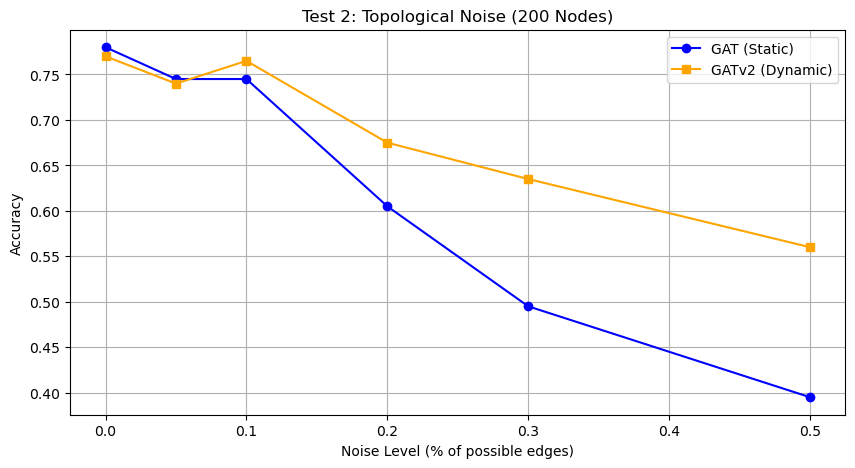

In [56]:
import torch
import matplotlib.pyplot as plt

# 1. RESET EVERYTHING
topo_gat_results = []
topo_gatv2_results = []
noise_levels = [0, 0.05, 0.1, 0.2, 0.3, 0.5]
num_nodes = 200

# Ensure data is synced
x = torch.randn((num_nodes, 8))
labels = torch.zeros(num_nodes, dtype=torch.long)
half = num_nodes // 2
for i in range(half): labels[i] = i + half
for i in range(half, num_nodes): labels[i] = i
base_adj = generate_noisy_dictionary(num_nodes=200, k=1)

# 2. THE LOOP
for level in noise_levels:
    print(f"🔄 Processing noise level: {level*100:.0f}%")
    
    noisy_adj = add_topological_noise(base_adj, noise_level=level)
    
    # --- TRAIN GAT ---
    m_gat = GAT_Model(nfeat=8, nhid=4, nclass=num_nodes, dropout=0.1, alpha=0.2, nheads=1)
    acc_gat = train_and_eval(m_gat, x, noisy_adj, labels, epochs=500) # Slightly fewer epochs for speed
    topo_gat_results.append(acc_gat)
    
    # --- TRAIN GATv2 ---
    # Double check this class name matches your definition!
    m_v2 = GATv2_Model(nfeat=8, nhid=4, nclass=num_nodes, dropout=0.1, alpha=0.2, nheads=1)
    acc_v2 = train_and_eval(m_v2, x, noisy_adj, labels, epochs=500)
    topo_gatv2_results.append(acc_v2)
    
    print(f"   Done! GAT: {acc_gat:.2f} | GATv2: {acc_v2:.2f}")

# 3. PLOT IMMEDIATELY
plt.figure(figsize=(10, 5))
plt.plot(noise_levels, topo_gat_results, 'o-', label='GAT (Static)', color='blue')
plt.plot(noise_levels, topo_gatv2_results, 's-', label='GATv2 (Dynamic)', color='orange')
plt.xlabel('Noise Level (% of possible edges)')
plt.ylabel('Accuracy')
plt.title('Test 2: Topological Noise (200 Nodes)')
plt.legend()
plt.grid(True)
plt.show()